<a href="https://colab.research.google.com/github/tort-cam/ST554HW5/blob/main/HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Homework 5!

Author: Cameron Mullaney

\
This homework covers the concepts covered in the most recent few weeks of ST 554, focusing on big data applications, ML model bias, and SQL Queries.

###Part I - Concepts

Answering questions 1-3 on the homework

##### 1 - Five V's
1. I have never encountered "big data" in my professional life, but I can certainly imagine encountering it in my future. As a environmental scientist, there will be times when I need to pull weather, GPS, water temperature, and much more from places all around the world at the same time, a task perfectly suited to a SQL platform. I've handled data close to this scale, storing CSVs with nearly 1,000,000 lines, but I've always stored them on a local drive and handled them in R.
 - Environmental data vary greatly in their frequency, ranging from more than once per second to less than once per day. The high-frequency data adds up very quick, resulting in an immense **volume** of data even if it's just over a few days. This **velocity** can be a challenge to handle, and often daily or hourly means are used to simplify comparisons with less frequent data types.
 - These data are often recorded as numeric values, but other data types make an appearance - I've processed audio and video data in tandem with these numeric types (Temperature, Latitude/Longitude, etc). This **variety** makes for more complicated analyses, but often more informative results.
 - Any measurement data we use has inherent variability. In my work so far, we have had hundreds of thousands of  observations, which helps to reduce the impact of this **veracity**, and we have still been able to evaluate the overarching trends over time, even though no two observations are identical for the same subject / location.
 - As an environmental scientist working for the government, the **value** of our work was learn more about, and therefore better protect the natural world. This value is often in dispute as it is not directly financial, but NOAA is always working to remind people that their goals are of benefit to everyone.

##### 2 - CRUD
2. **Create** - Creating a column for player's full names, as opposed to First/Last columns\
  **Read** - Pulling in a list of every Padres player ever\
  **Update** - Correcting an error in a previous year's data\
  **Delete** - For this assignment, we don't need all-star data, so we can delete that from our local database.

##### 3 - `HAVING`
3. The `HAVING` clause allows you to further narrow your `SELECT` request for each `GROUP BY` group you have.


###Part II - Simulation of a Sampling Distribution

Here I load in the modules I'll need, create some data, and then analyze that data and discuss applications of my methods.

#####Loading in the Modules

In [48]:
## Necessary Modules
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model
import sklearn.metrics as metrics
import seaborn as sns

#####Creating the data

In [194]:
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
slopes = []
lm = linear_model.LinearRegression()

for i in range(0,5000) :
# get three 'values' of x at each integer from 0 to 10.
  x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
  n = 33

#create the 'responses' modeled from the line plus a random deviation
  y = beta_0 + beta_1*x + rng.standard_normal(n)
  lm.fit(x.reshape(-1,1), y)

## Here lm's coefficients are in a 1D ndarray, so I am taking the "minimum" from each cell, returning the float value within.
  slopes.append(lm.coef_.min())

##### Slope Histogram

<Axes: ylabel='Count'>

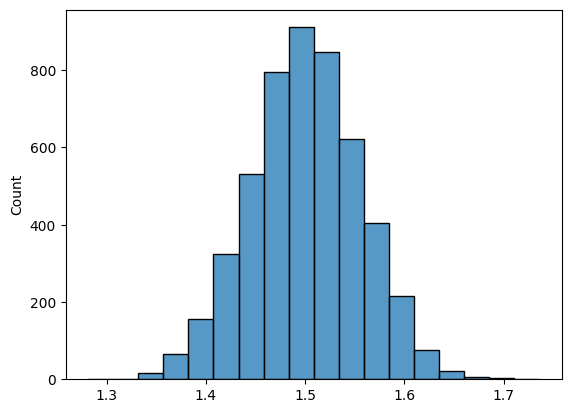

In [36]:
sns.histplot(slopes, binwidth = .025)

##### Probability Calculation

In [47]:
slopes_sub = [x for x in slopes if x > 1.65]
print("Probability of Sample Slope > 1.65:\t", len(slopes_sub)/len(slopes))

Probability of Sample Slope > 1.65:	 0.0038


##### Interpretation

This gives us an idea of the variance within the sample - The normal distribution above shows us that the data's variance in best-fit slope is ~normally distributed. This value can provide insight into the variance in the samples, and we can use this to determine a confidence interval for the slope, as well as evaulate the likelihood of the true value being above or (much more likley) below this value. This 1.65 cutoff can be set to whatever we want, to get the best idea of the population distribution.

### Part III - Big Data & Rare Events

This section features my thoughts on the assigned articles for this homework.

##### 5 - Bias in ML Models

This article brings up an example of a ML image recognition model, which was disproportionately associating pictures of kitchens with women. They realized that this came about because the training data (i.e. the images the model was trained on) had more pictures of women in a kitchen environment than men in such places. This model was trained on biased data, and as a result, showed this same bias when used.

This is a particularly challenging scenario to try to account for, because this bias is very prevalent in society - as much as this model is biased (problematically), it is an accurate depiction of the world we've created. To account for / correct for this, you *could* try to feed the model less biased data, but this would be an immense (and perhaps fruitless) undertaking. It would be more effective to manually correct the model, giving it some sort of negative factor in specific correlations. This is not without its issues either, as it requires us to recognize and evaluate every bias and connection the model makes.

##### 6 - Earth Sciences

This article discusses the use of big data to model the "full 3D Ocean". This has historically been done through a network of buoys floating in the tropical Pacific, all collecting and uploading air/water temperature, wind speed, GPS, salinity, and much more. These unfortunately do not gather data at depth, leaving us with a "2D Ocean", so we recently (in the last 20 years) began deploying underwater probes, vehicles, etc. to collect data at depth, swiftly  increasing the volume of data to the levels necessitating a "big data" approach.

As the article displays in Figure 2, there has been a massive increase in ocean data being collected from 1995-now. This as enabled more thorough modeling of the ocean, but it's still clear that certain places are lacking in data, especially in Eastern Asia. The South China Sea, East China Sea, and Sea of Japan are all in the lowest data volume category.

This means that models trained on this surface temperature data will be better informed on the patterns of the Atlantic and Eastern Pacific (US-side), and South Indian oceans, and likely use the trends seen there to assume the characteristics of these less-mapped waters, resulting in what may be incorrect assumptions.

##### 7 - Rare Events

Cool article! I think for something like Sports viewership on TV, this "rare event" would be important to keep in mind. For every game in a given sport, viewership varies from game to game, but something like the superbowl gets magnitudes more viewership than a random mid-season game. It only happens once a year so it's likelihood is lower, but when it happens, you see a much higher viewership.

### Part IV - Querying a Database

Here, I will load in a database from my google drive, and use SQLite to perform a variety of actions including subsetting, joining, and summing on the data within.

In [67]:
import pandas as pd
import sqlite3
## I've uploaded the sqlite file to my Google Drive
%cd /content/drive/MyDrive/Colab_Notebooks/Colab_data


/content/drive/MyDrive/Colab_Notebooks/Colab_data


##### 8 - Database Connection

In [69]:
con = sqlite3.connect("lahman_1871-2022.sqlite")
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''
data = pd.read_sql(get_schema, con)
data

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


##### 9 - 2015 Teams

In [79]:
get_2015teams = '''
        SELECT *
        FROM Teams
        WHERE yearID = 2015;
        '''
teams2015 = pd.read_sql(get_2015teams, con)
teams2015

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


##### 10 - All HOFers w/ year, ID

Without Name

In [101]:
get_hof = '''

        SELECT playerID, yearid, category FROM HallOfFame
        WHERE inducted = "Y";
        '''

hof = pd.read_sql(get_hof, con)
hof

,playerID,yearid,category
0,aaronha01,1982,Player
1,alexape01,1938,Player
2,alomaro01,2011,Player
3,alstowa01,1983,Manager
4,andersp01,2000,Manager
...,...,...,...
335,yastrca01,1989,Player
336,yawketo99,1980,Pioneer/Executive
337,youngcy01,1937,Player
338,youngro01,1972,Player


With Name

In [99]:
get_hof = '''
        WITH hof as (
          SELECT playerID, yearid, category FROM HallOfFame
          WHERE inducted = "Y"),
        p as (
          SELECT playerID, nameGiven, nameLast from People )

        SELECT * FROM hof
        LEFT JOIN p ON hof.playerID = p.playerID
        ;

        '''

hof = pd.read_sql(get_hof, con)

,playerID,yearid,category,playerID,nameGiven,nameLast
0,aaronha01,1982,Player,aaronha01,Henry Louis,Aaron
1,alexape01,1938,Player,alexape01,Grover Cleveland,Alexander
2,alomaro01,2011,Player,alomaro01,Roberto,Alomar
3,alstowa01,1983,Manager,alstowa01,Walter Emmons,Alston
4,andersp01,2000,Manager,andersp01,George Lee,Anderson
...,...,...,...,...,...,...
335,yastrca01,1989,Player,yastrca01,Carl Michael,Yastrzemski
336,yawketo99,1980,Pioneer/Executive,yawketo99,Thomas Austin,Yawkey
337,youngcy01,1937,Player,youngcy01,Denton True,Young
338,youngro01,1972,Player,youngro01,Royce Middlebrook,Youngs


##### 11 - Unique PIT Managers

In [128]:
get_pitman = '''

        SELECT DISTINCT playerID, teamID FROM Managers
        WHERE teamID = "PIT";
        '''

pitman = pd.read_sql(get_pitman, con)
pitman
## This returs a DF of each manager the Pirates have had, and no other info.
## "and only that information from the Managers table"

,playerID,teamID
0,bezdehu99,PIT
1,bragabo01,PIT
2,buckeal99,PIT
3,burnsto01,PIT
4,burwebi01,PIT
5,bushdo01,PIT
6,callani01,PIT
7,clarkfr01,PIT
8,davissp01,PIT
9,donovpa01,PIT


##### 12 - All Hall of Famers who managed

In [192]:
get_hofman = '''
        SELECT DISTINCT hof.playerID FROM HallOfFame as hof
        LEFT JOIN Managers as m ON hof.playerID = m.playerID
        WHERE inducted = "Y";
        '''

hofman = pd.read_sql(get_hofman, con)
print("Number of people who managed and are in the HOF:\t", len(hofman))
hofman

Number of people who managed and are in the HOF:	 340


,playerID
0,aaronha01
1,alexape01
2,alomaro01
3,alstowa01
4,andersp01
...,...
335,yastrca01
336,yawketo99
337,youngcy01
338,youngro01


##### 13 - Seasonal Records and Win %

In [172]:
get_records = '''
    SELECT m.playerID, m.G, m.W, m.L, m.yearID FROM HallOfFame AS hof
    LEFT JOIN Managers AS m ON hof.playerID = m.playerID
    WHERE hof.inducted = "Y" AND m.playerID IS NOT NULL
    '''

records = pd.read_sql(get_records, con)
records

,playerID,G,W,L,yearID
0,alstowa01,154,92,62,1954
1,alstowa01,154,98,55,1955
2,alstowa01,154,93,61,1956
3,alstowa01,154,84,70,1957
4,alstowa01,154,71,83,1958
...,...,...,...,...,...
991,wrighha01,46,22,23,1890
992,wrighha01,138,68,69,1891
993,wrighha01,155,87,66,1892
994,wrighha01,133,72,57,1893


In [193]:
career = '''
    SELECT m.playerID, SUM(m.G) AS games, SUM(m.W) AS win, SUM(m.L) AS loss FROM HallOfFame AS hof
    LEFT JOIN Managers AS m ON hof.playerID = m.playerID
    WHERE hof.inducted = "Y" AND m.playerID IS NOT NULL
    GROUP BY m.playerID
    '''

c = pd.read_sql(career, con)
c['wl'] = (c.win/(c.win+c.loss))
c_sorted = c.sort_values("wl", ascending = False) ## Reordered by "wl" value
c_sorted


,playerID,games,win,loss,wl
75,simmote01,1,1,0,1.000000
94,wrighge01,85,59,25,0.702381
78,spaldal01,126,78,47,0.624000
57,mccarjo99,3487,2125,1333,0.614517
19,comisch01,1410,840,541,0.608255
...,...,...,...,...,...
8,bottoji01,78,21,56,0.272727
3,applilu01,40,10,30,0.250000
4,baineha01,4,1,3,0.250000
86,wagneho01,5,1,4,0.200000
